## 1장 2강: 데이터 분석 기초

### 2. 탐색적 데이터 분석(EDA, Exploratory Data Analysis)과 결측치/이상치

### 4. 타이타닉(Titanic) 탑승객 데이터 분석
#### 4.1 데이터 로드 및 결측치, 이상치 처리

타이타닉(Titanic) 탑승객 데이터 로드 하기

In [70]:
import sys
print(sys.executable)

c:\Users\yangc\Desktop\Code\AX_Study\04_MACHINE_LEARNING\.venv\Scripts\python.exe


In [71]:
import pandas as pd
import numpy as npm
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("titanic")
df
df.iloc[:5]
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [72]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

데이터 요약 및 통계 확인 하기

In [73]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


결측치 파악하기

In [74]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

숫자형 데이터(나이): 전체 탑승객의 '평균(mean)'으로 빈칸 채우기

In [75]:
mean_age = df['age'].mean()
print("평균 나이: ", mean_age)

df['age'] = df['age'].fillna(mean_age)

df.isna().sum()

평균 나이:  29.69911764705882


survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

문자/범주형 데이터(탑승 항구): 가장 많이 탑승한 곳인 '최빈값(mode)'으로 빈칸 채우기

In [76]:
mode_embarked = df['embark_town'].mode()[0]
mode_embarked

df['embark_town'] = df['embark_town'].fillna(mode_embarked)
df['embarked'] = df['embark_town'].map(lambda x : x[0].upper())

df.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

특정 컬럼(deck) 을 '기준'으로 좌우(열 방향) 데이터를 채우기

In [77]:
df['deck'] = df['deck'].ffill()
df['deck'] = df['deck'].bfill()

df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

너무 비싼 요금(이상치) 걸러내기

요금 평균 32.204207968574636
요금 중간값 14.4542


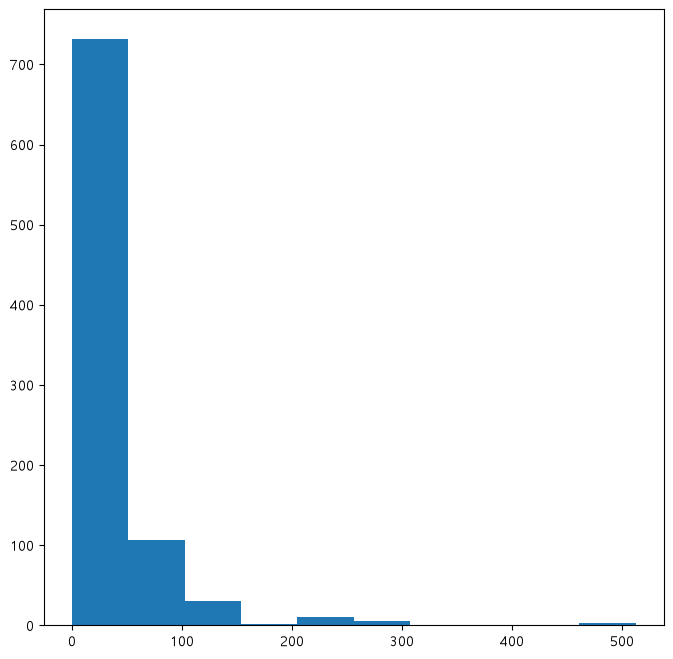

In [78]:
print("요금 평균", df['fare'].mean())
print("요금 중간값", df['fare'].median())

plt.figure(figsize=(8,8))
plt.hist(df['fare'], bins=10)
plt.show()

In [79]:
df = df[df['fare'] <= 300]

결측치/이상치 보완 결과 확인

In [80]:
df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [81]:
df[df['fare'] > 300].count()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

#### 4.2 중복 데이터 처리하기

중복 데이터 확인하기

In [82]:
df.duplicated().sum()

np.int64(39)

중복 데이터 제거하기
- drop_duplicates() : 중복 행 삭제

In [83]:
df.drop_duplicates()[:30]
df = df.drop_duplicates().reset_index(drop=True)

print("중복 데이터 수: ", df.duplicated().sum())

중복 데이터 수:  0


#### 4.3 그래프로 시각화하기

내 컴퓨터에 맞는 한글 폰트 설정하기

In [84]:
import platform
from matplotlib import rc

os_name = platform.system()

if os_name == 'Windows':
    rc("font", family="Malgun Gothic")
else:
    rc("font", family="AppleGothic")

도화지(Figure)와 3개의 액자(Axes) 준비

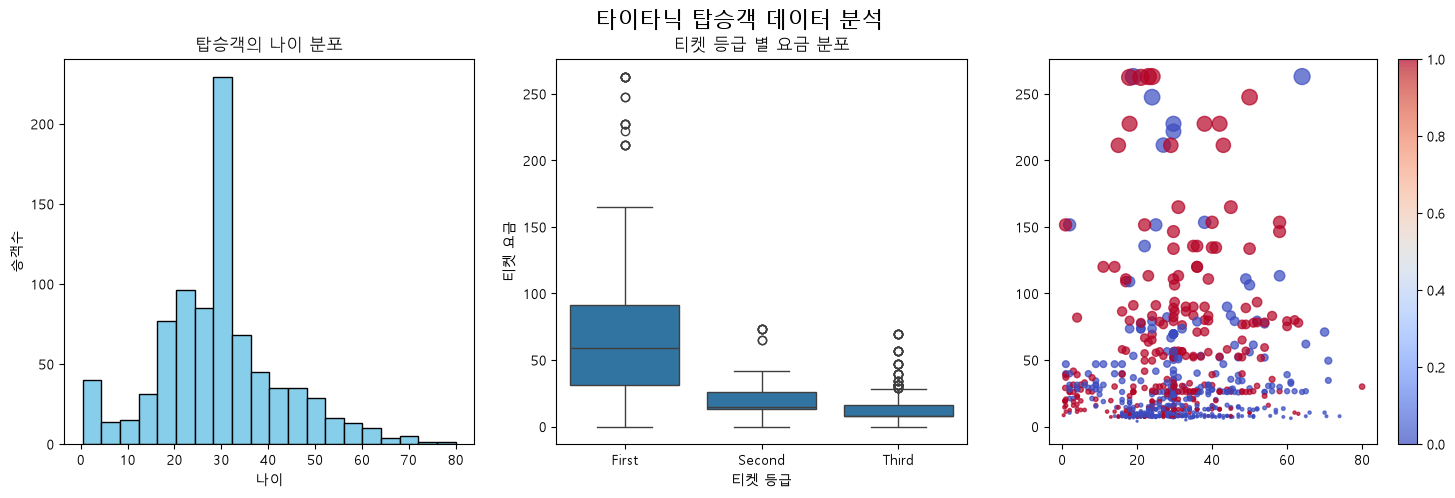

In [113]:
fig, axes = plt.subplots(1,3, figsize=(18, 5))

fig.suptitle("타이타닉 탑승객 데이터 분석", fontsize=16)

# [히스토그램] 탑승객 나이 분포
axes[0].hist(df['age'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title("탑승객의 나이 분포")
axes[0].set_xlabel('나이')
axes[0].set_ylabel('승객수')

# [박스 플롯] 티켓 등급에 따른 요금 이상치 확인
sns.boxplot(x="class", y="fare", data=df, ax=axes[1])
axes[1].set_title('티켓 등급 별 요금 분포')
axes[1].set_xlabel('티켓 등급')
axes[1].set_ylabel('티켓 요금')

# [산점도] 나이와 클리닝된 요금의 관계
scatter = axes[2].scatter(df['age'], df['fare'], c=df['survived'], cmap="coolwarm", s=df['fare'] / 2, alpha=0.7) # 1 - 빨강, 0 - 파람

fig.colorbar(scatter)

그래프로 분석하기